# Análisis y Clasificación de Tickets de Soporte

**Objetivo:** Analizar el dataset de tickets y entrenar modelos de clasificación supervisada para predecir el tipo de ticket basándose en sus características.

**Autor:** Joan Linares  
**Fecha:** Marzo 2026

## 1. Importación de Librerías

In [1]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Librerías de preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB, GaussianNB

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 2. Exploración de Datos (EDA)

En esta sección analizaremos el dataset para comprender su estructura, distribución y características principales.

### 2.1 Carga y Vista Inicial del Dataset

In [2]:
# Cargar el dataset
df = pd.read_csv('../data/aa_dataset-tickets-multi-lang-5-2-50-version.csv')

print("═" * 80)
print("INFORMACIÓN GENERAL DEL DATASET")
print("═" * 80)
print(f"\n📊 Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas\n")

# Mostrar primeras filas
df.head()

════════════════════════════════════════════════════════════════════════════════
INFORMACIÓN GENERAL DEL DATASET
════════════════════════════════════════════════════════════════════════════════

📊 Dimensiones del dataset: 28587 filas x 16 columnas



,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


### 2.2 Información de Variables y Tipos de Datos

In [ ]:
# Información detallada del dataset
print("\n" + "="*80)
print("INFORMACIÓN DETALLADA DE LAS VARIABLES")
print("="*80 + "\n")
df.info()

print("\n" + "="*80)
print("VALORES NULOS POR COLUMNA")
print("="*80 + "\n")
missing_data = pd.DataFrame({
    'Columna': df.columns,
    'Valores Nulos': df.isnull().sum().values,
    'Porcentaje (%)': (df.isnull().sum().values / len(df) * 100).round(2)
})
print(missing_data.to_string(index=False))

print("\n" + "="*80)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("="*80 + "\n")
df.describe(include='all').T

**Interpretación:**
- El dataset contiene información sobre tickets de soporte con texto (subject, body, answer) y metadatos (type, queue, priority, language, etc.)
- Las variables categóricas incluyen: type, queue, priority, language, version y múltiples tags
- Las variables de texto incluyen: subject, body, answer
- Es importante revisar valores nulos y decidir cómo tratarlos

### 2.3 Distribución de la Variable Objetivo


DISTRIBUCIÓN DE LA VARIABLE OBJETIVO: TYPE

    Tipo  Cantidad  Porcentaje (%)
Incident     11466           40.11
 Request      8187           28.64
 Problem      6012           21.03
  Change      2922           10.22


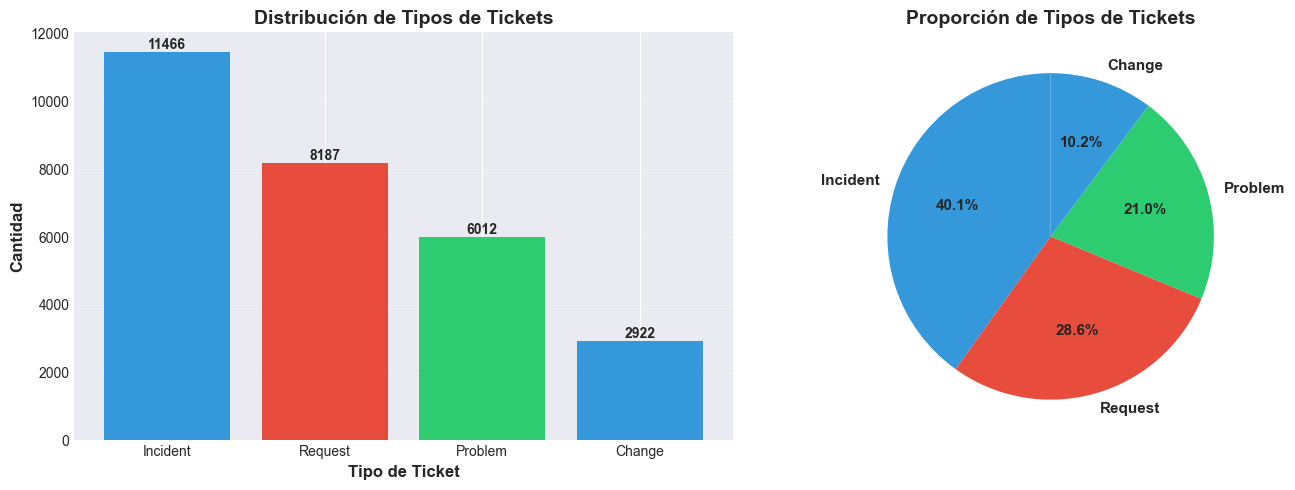

In [3]:
# Análisis de la variable objetivo: 'type'
print("\n" + "="*80)
print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO: TYPE")
print("="*80 + "\n")

type_counts = df['type'].value_counts()
type_percentages = df['type'].value_counts(normalize=True) * 100

type_distribution = pd.DataFrame({
    'Tipo': type_counts.index,
    'Cantidad': type_counts.values,
    'Porcentaje (%)': type_percentages.values.round(2)
})
print(type_distribution.to_string(index=False))

# Gráfico de distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(type_counts.index, type_counts.values, color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_xlabel('Tipo de Ticket', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cantidad', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Tipos de Tickets', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

# Gráfico de pastel
colors = ['#3498db', '#e74c3c', '#2ecc71']
axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=colors, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Proporción de Tipos de Tickets', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretación:**
- La distribución muestra la cantidad de cada tipo de ticket (Incident, Request, Problem)
- Este análisis permite identificar si existe desbalanceo de clases en el dataset

### 2.4 Análisis de Desbalanceo de Clases

In [4]:
# Calcular el ratio de desbalanceo
max_class = type_counts.max()
min_class = type_counts.min()
imbalance_ratio = max_class / min_class

print("\n" + "="*80)
print("ANÁLISIS DE DESBALANCEO DE CLASES")
print("="*80 + "\n")
print(f"📈 Clase mayoritaria: {type_counts.idxmax()} con {max_class} instancias")
print(f"📉 Clase minoritaria: {type_counts.idxmin()} con {min_class} instancias")
print(f"⚖️  Ratio de desbalanceo: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 3:
    print("\n⚠️  ADVERTENCIA: Existe un desbalanceo significativo de clases.")
    print("   Considerar técnicas de balanceo (oversampling, undersampling, SMOTE)")
elif imbalance_ratio > 1.5:
    print("\n⚠️  ATENCIÓN: Existe un desbalanceo moderado de clases.")
else:
    print("\n✓ Las clases están relativamente balanceadas.")


ANÁLISIS DE DESBALANCEO DE CLASES

📈 Clase mayoritaria: Incident con 11466 instancias
📉 Clase minoritaria: Change con 2922 instancias
⚖️  Ratio de desbalanceo: 3.92:1

⚠️  ADVERTENCIA: Existe un desbalanceo significativo de clases.
   Considerar técnicas de balanceo (oversampling, undersampling, SMOTE)


### 2.5 Análisis de Otras Variables Categóricas

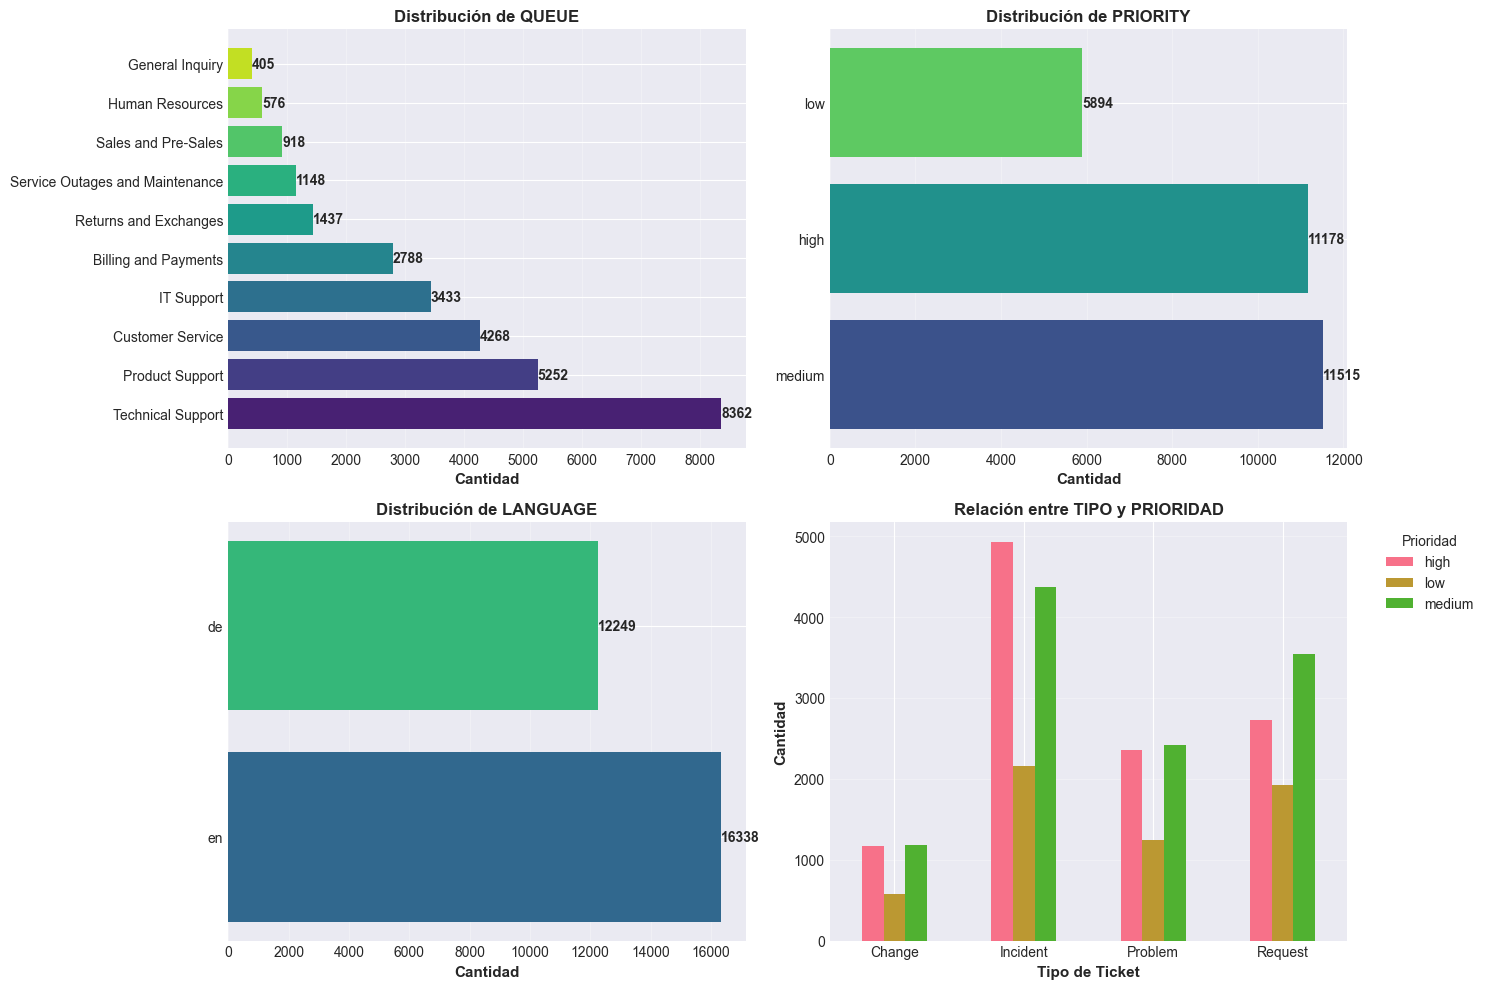

In [5]:
# Distribución de variables categóricas clave
categorical_vars = ['queue', 'priority', 'language']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_vars):
    if col in df.columns:
        counts = df[col].value_counts().head(10)
        axes[idx].barh(counts.index, counts.values, color=sns.color_palette("viridis", len(counts)))
        axes[idx].set_xlabel('Cantidad', fontsize=11, fontweight='bold')
        axes[idx].set_title(f'Distribución de {col.upper()}', fontsize=12, fontweight='bold')
        axes[idx].grid(axis='x', alpha=0.3)
        
        # Añadir valores en las barras
        for i, v in enumerate(counts.values):
            axes[idx].text(v + 0.1, i, str(v), va='center', fontweight='bold')

# Relación entre type y priority
if 'priority' in df.columns:
    pd.crosstab(df['type'], df['priority']).plot(kind='bar', ax=axes[3], rot=0)
    axes[3].set_xlabel('Tipo de Ticket', fontsize=11, fontweight='bold')
    axes[3].set_ylabel('Cantidad', fontsize=11, fontweight='bold')
    axes[3].set_title('Relación entre TIPO y PRIORIDAD', fontsize=12, fontweight='bold')
    axes[3].legend(title='Prioridad', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[3].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación:**
- **Queue:** Muestra las categorías o departamentos más comunes de tickets
- **Priority:** Indica la distribución de prioridades (high, medium, low)
- **Language:** Revela los idiomas predominantes en los tickets
- La relación entre tipo y prioridad ayuda a entender patrones en la clasificación de tickets

### 2.6 Análisis de Variables de Texto

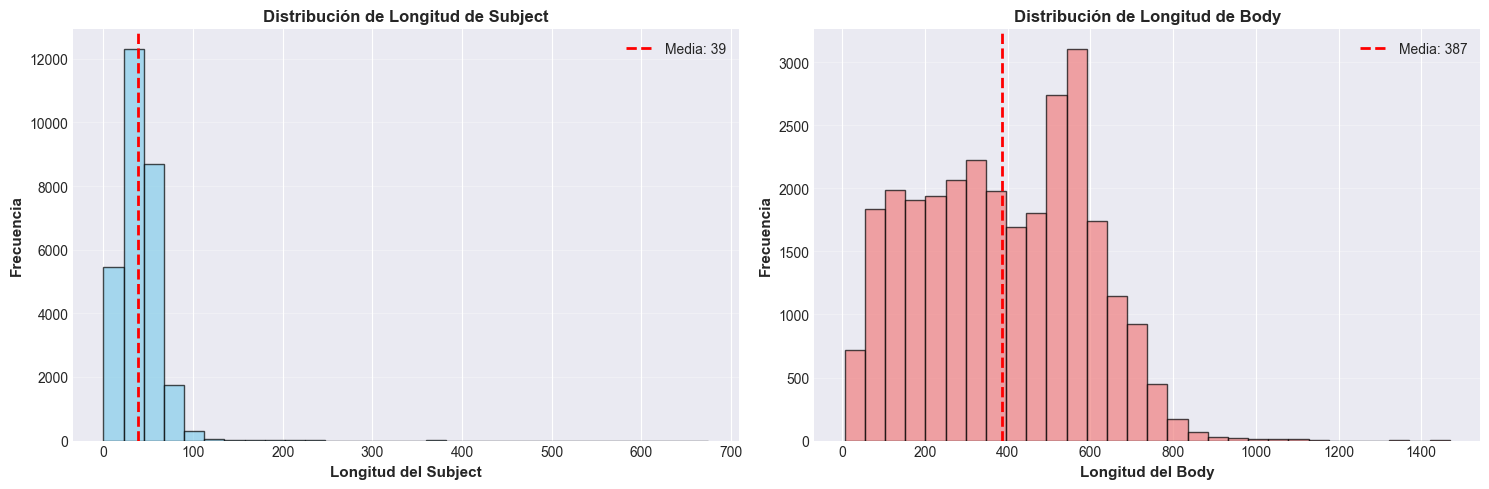


ESTADÍSTICAS DE LONGITUD DE TEXTO

       subject_length   body_length
count    28587.000000  28587.000000
mean        38.546122    387.263896
std         23.672887    200.129011
min          0.000000      6.000000
25%         27.000000    219.000000
50%         39.000000    386.000000
75%         51.000000    551.000000
max        675.000000   1469.000000


In [6]:
# Análisis de longitud de texto
df['subject_length'] = df['subject'].fillna('').astype(str).apply(len)
df['body_length'] = df['body'].fillna('').astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma de longitud de subject
axes[0].hist(df['subject_length'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Longitud del Subject', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[0].set_title('Distribución de Longitud de Subject', fontsize=12, fontweight='bold')
axes[0].axvline(df['subject_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["subject_length"].mean():.0f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Histograma de longitud de body
axes[1].hist(df['body_length'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Longitud del Body', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[1].set_title('Distribución de Longitud de Body', fontsize=12, fontweight='bold')
axes[1].axvline(df['body_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["body_length"].mean():.0f}')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ESTADÍSTICAS DE LONGITUD DE TEXTO")
print("="*80 + "\n")
print(df[['subject_length', 'body_length']].describe())

**Interpretación:**
- La longitud del texto (subject y body) varía considerablemente entre tickets
- Esto es relevante para el preprocesamiento de texto y la extracción de características

### 2.7 Análisis de Tags


📌 Número de columnas de tags: 8

TOP 15 TAGS MÁS FRECUENTES

          Tag  Frecuencia
 Tech Support       16505
           IT       16325
  Performance       13374
     Feedback        7937
          Bug        7492
     Security        7046
      Feature        6660
Documentation        6167
   Disruption        5744
       Outage        4364
      Network        3693
      Product        2503
     Recovery        2494
        Sales        2432
     Hardware        1569


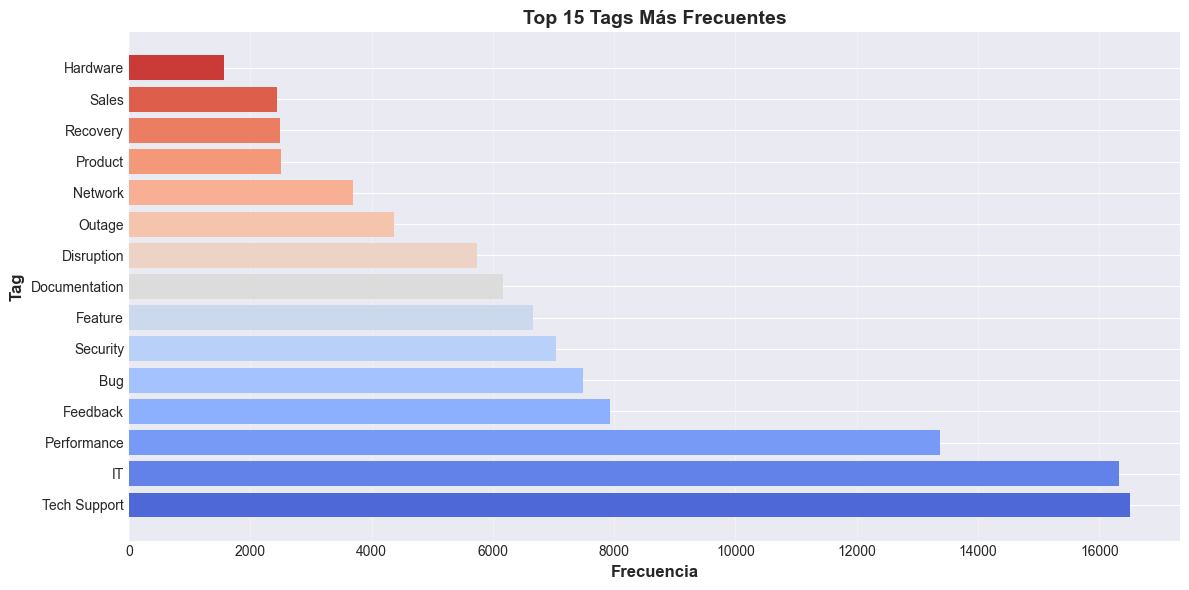

In [7]:
# Análisis de tags
tag_cols = [col for col in df.columns if col.startswith('tag_')]
print(f"\n📌 Número de columnas de tags: {len(tag_cols)}\n")

# Contar tags más frecuentes
all_tags = []
for col in tag_cols:
    all_tags.extend(df[col].dropna().values)

from collections import Counter
tag_counts = Counter(all_tags)
top_tags = pd.DataFrame(tag_counts.most_common(15), columns=['Tag', 'Frecuencia'])

print("="*80)
print("TOP 15 TAGS MÁS FRECUENTES")
print("="*80 + "\n")
print(top_tags.to_string(index=False))

# Visualización
plt.figure(figsize=(12, 6))
plt.barh(top_tags['Tag'], top_tags['Frecuencia'], color=sns.color_palette("coolwarm", len(top_tags)))
plt.xlabel('Frecuencia', fontsize=12, fontweight='bold')
plt.ylabel('Tag', fontsize=12, fontweight='bold')
plt.title('Top 15 Tags Más Frecuentes', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación:**
- Los tags proporcionan información adicional sobre la naturaleza del ticket
- Los tags más frecuentes pueden ser características importantes para la clasificación

## 3. Preparación de Datos

En esta sección prepararemos los datos para el entrenamiento de modelos de machine learning.

### 3.1 Selección y Creación de Features

In [8]:
# Crear una copia del dataframe
df_ml = df.copy()

# Eliminar valores nulos en la variable objetivo
df_ml = df_ml[df_ml['type'].notna()].reset_index(drop=True)

print(f"✓ Instancias después de eliminar valores nulos en 'type': {len(df_ml)}")

# Combinar texto de subject y body para crear una feature de texto completa
df_ml['text_combined'] = (df_ml['subject'].fillna('') + ' ' + df_ml['body'].fillna('')).str.strip()

# Rellenar valores nulos en variables categóricas
categorical_features = ['queue', 'priority', 'language']
for col in categorical_features:
    if col in df_ml.columns:
        df_ml[col] = df_ml[col].fillna('unknown')

print(f"✓ Features categóricas preparadas: {categorical_features}")
print(f"✓ Feature de texto creada: text_combined")

✓ Instancias después de eliminar valores nulos en 'type': 28587
✓ Features categóricas preparadas: ['queue', 'priority', 'language']
✓ Feature de texto creada: text_combined


### 3.2 Codificación de Variables Categóricas

In [9]:
# Codificar variables categóricas
label_encoders = {}

for col in categorical_features:
    if col in df_ml.columns:
        le = LabelEncoder()
        df_ml[f'{col}_encoded'] = le.fit_transform(df_ml[col])
        label_encoders[col] = le
        print(f"✓ Variable '{col}' codificada: {len(le.classes_)} categorías únicas")

✓ Variable 'queue' codificada: 10 categorías únicas
✓ Variable 'priority' codificada: 3 categorías únicas
✓ Variable 'language' codificada: 2 categorías únicas


### 3.3 Vectorización de Texto con TF-IDF

In [10]:
# Vectorización de texto usando TF-IDF
print("\n📝 Aplicando TF-IDF Vectorization...\n")

tfidf = TfidfVectorizer(
    max_features=100,  # Limitar a las 100 características más importantes
    min_df=2,           # Ignorar términos que aparecen en menos de 2 documentos
    max_df=0.8,         # Ignorar términos que aparecen en más del 80% de los documentos
    ngram_range=(1, 2), # Usar unigramas y bigramas
    stop_words='english'
)

text_features = tfidf.fit_transform(df_ml['text_combined'])
text_features_df = pd.DataFrame(
    text_features.toarray(), 
    columns=[f'tfidf_{i}' for i in range(text_features.shape[1])]
)

print(f"✓ Vectorización completada: {text_features.shape[1]} características de texto generadas")


📝 Aplicando TF-IDF Vectorization...

✓ Vectorización completada: 100 características de texto generadas


### 3.4 Creación de Dataset Final

In [14]:
# Combinar todas las features
feature_cols = [f'{col}_encoded' for col in categorical_features if col in df_ml.columns]
feature_cols += ['subject_length', 'body_length']

# Crear matriz de features X
X_categorical = df_ml[feature_cols].values
X_combined = np.hstack([X_categorical, text_features.toarray()])

# Variable objetivo y - convertir a numpy array estándar
y = np.array(df_ml['type'].astype(str))

print("\n" + "="*80)
print("DATASET FINAL PARA MACHINE LEARNING")
print("="*80 + "\n")
print(f"📊 Dimensiones de X (features): {X_combined.shape}")
print(f"📊 Dimensiones de y (target): {y.shape}")
print(f"\n✓ Total de features utilizadas: {X_combined.shape[1]}")
print(f"  - Features categóricas: {len(feature_cols) - 2}")
print(f"  - Features de longitud de texto: 2")
print(f"  - Features TF-IDF: {text_features.shape[1]}")


DATASET FINAL PARA MACHINE LEARNING

📊 Dimensiones de X (features): (28587, 105)
📊 Dimensiones de y (target): (28587,)

✓ Total de features utilizadas: 105
  - Features categóricas: 3
  - Features de longitud de texto: 2
  - Features TF-IDF: 100


### 3.5 División en Conjuntos de Entrenamiento y Test

In [15]:
# Dividir datos en train y test con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("\n" + "="*80)
print("DIVISIÓN DE DATOS")
print("="*80 + "\n")
print(f"📈 Conjunto de entrenamiento: {X_train.shape[0]} instancias ({X_train.shape[0]/len(X_combined)*100:.1f}%)")
print(f"📉 Conjunto de test: {X_test.shape[0]} instancias ({X_test.shape[0]/len(X_combined)*100:.1f}%)")

# Verificar distribución de clases en train y test
print("\n📊 Distribución de clases en TRAIN:")
train_dist = pd.Series(y_train).value_counts()
for cls, count in train_dist.items():
    print(f"   {cls}: {count} ({count/len(y_train)*100:.1f}%)")

print("\n📊 Distribución de clases en TEST:")
test_dist = pd.Series(y_test).value_counts()
for cls, count in test_dist.items():
    print(f"   {cls}: {count} ({count/len(y_test)*100:.1f}%)")


DIVISIÓN DE DATOS

📈 Conjunto de entrenamiento: 22869 instancias (80.0%)
📉 Conjunto de test: 5718 instancias (20.0%)

📊 Distribución de clases en TRAIN:
   Incident: 9173 (40.1%)
   Request: 6549 (28.6%)
   Problem: 4809 (21.0%)
   Change: 2338 (10.2%)

📊 Distribución de clases en TEST:
   Incident: 2293 (40.1%)
   Request: 1638 (28.6%)
   Problem: 1203 (21.0%)
   Change: 584 (10.2%)


**¿Por qué es necesaria esta separación?**

1. **Evitar sobreajuste (overfitting):** El conjunto de test actúa como datos "no vistos" para evaluar la capacidad de generalización del modelo
2. **Evaluación realista:** Simula cómo funcionará el modelo con datos nuevos en producción
3. **Validación independiente:** Permite medir el rendimiento real del modelo sin sesgo de entrenamiento
4. **Estratificación:** Mantiene la proporción de clases en ambos conjuntos, crucial para datos desbalanceados

### 3.6 Escalado de Features (Opcional)

In [16]:
# Escalar features (importante para algunos modelos como SVM, KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features escaladas con StandardScaler")
print("  (Requerido para modelos sensibles a escala: SVM, KNN, Logistic Regression)")

✓ Features escaladas con StandardScaler
  (Requerido para modelos sensibles a escala: SVM, KNN, Logistic Regression)


## 4. Entrenamiento de Modelos de Clasificación

Probaremos múltiples algoritmos de clasificación supervisada para determinar cuál funciona mejor con nuestros datos.

### 4.1 Definición de Modelos

In [17]:
# Diccionario de modelos a evaluar
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (Linear)': SVC(kernel='linear', random_state=42, probability=True),
    'Naive Bayes': GaussianNB()
}

print("\n" + "="*80)
print("MODELOS A EVALUAR")
print("="*80 + "\n")
for i, (name, model) in enumerate(models.items(), 1):
    print(f"{i}. {name}")
print("\n✓ Total de modelos: ", len(models))


MODELOS A EVALUAR

1. Logistic Regression
2. KNN (k=5)
3. Decision Tree
4. Random Forest
5. Gradient Boosting
6. SVM (Linear)
7. Naive Bayes

✓ Total de modelos:  7


### 4.2 Entrenamiento y Predicciones

In [18]:
# Diccionario para almacenar resultados
results = {}

print("\n" + "="*80)
print("ENTRENANDO MODELOS...")
print("="*80 + "\n")

for name, model in models.items():
    print(f"🔄 Entrenando {name}...", end=' ')
    
    # Entrenar modelo (usar datos escalados para modelos sensibles)
    if name in ['Logistic Regression', 'KNN (k=5)', 'SVM (Linear)']:
        model.fit(X_train_scaled, y_train)
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
    
    # Guardar resultados
    results[name] = {
        'model': model,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred
    }
    
    print("✓")

print("\n✓ Todos los modelos entrenados exitosamente")


ENTRENANDO MODELOS...

🔄 Entrenando Logistic Regression... ✓
🔄 Entrenando KNN (k=5)... ✓
🔄 Entrenando Decision Tree... ✓
🔄 Entrenando Random Forest... ✓
🔄 Entrenando Gradient Boosting... ✓
🔄 Entrenando SVM (Linear)... ✓
🔄 Entrenando Naive Bayes... ✓

✓ Todos los modelos entrenados exitosamente


## 5. Evaluación de Modelos

Evaluaremos cada modelo usando múltiples métricas y matrices de confusión.

### 5.1 Métricas de Rendimiento

In [19]:
# Calcular métricas para todos los modelos
metrics_df = []

for name, result in results.items():
    y_train_pred = result['y_train_pred']
    y_test_pred = result['y_test_pred']
    
    # Métricas en train
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
    train_recall = recall_score(y_train, y_train_pred, average='weighted', zero_division=0)
    train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    
    # Métricas en test
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    
    metrics_df.append({
        'Modelo': name,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'Train Precision': train_precision,
        'Test Precision': test_precision,
        'Train Recall': train_recall,
        'Test Recall': test_recall,
        'Train F1-Score': train_f1,
        'Test F1-Score': test_f1,
        'Overfitting Gap': train_accuracy - test_accuracy
    })

metrics_df = pd.DataFrame(metrics_df)
metrics_df = metrics_df.round(4)

print("\n" + "="*80)
print("TABLA COMPARATIVA DE MÉTRICAS")
print("="*80 + "\n")
print(metrics_df.to_string(index=False))


TABLA COMPARATIVA DE MÉTRICAS

             Modelo  Train Accuracy  Test Accuracy  Train Precision  Test Precision  Train Recall  Test Recall  Train F1-Score  Test F1-Score  Overfitting Gap
Logistic Regression          0.7335         0.7314           0.7122          0.7085        0.7335       0.7314          0.6949         0.6921           0.0022
          KNN (k=5)          0.8367         0.7300           0.8353          0.7209        0.8367       0.7300          0.8333         0.7227           0.1067
      Decision Tree          0.7382         0.6840           0.7566          0.6629        0.7382       0.6840          0.7113         0.6470           0.0542
      Random Forest          0.7230         0.7006           0.8080          0.7944        0.7230       0.7006          0.6529         0.6122           0.0224
  Gradient Boosting          0.7577         0.7261           0.7609          0.7070        0.7577       0.7261          0.7239         0.6861           0.0316
       SVM (Li

**Justificación de Métricas:**

- **Accuracy:** Proporción de predicciones correctas. Útil cuando las clases están balanceadas.
- **Precision:** De todas las predicciones positivas, cuántas son correctas. Importante cuando el coste de falsos positivos es alto.
- **Recall:** De todas las instancias positivas reales, cuántas detectamos. Importante cuando el coste de falsos negativos es alto.
- **F1-Score:** Media armónica de precision y recall. Equilibra ambas métricas.
- **Overfitting Gap:** Diferencia entre train y test accuracy. Indica si el modelo se está sobreajustando.

### 5.2 Visualización de Comparación de Métricas

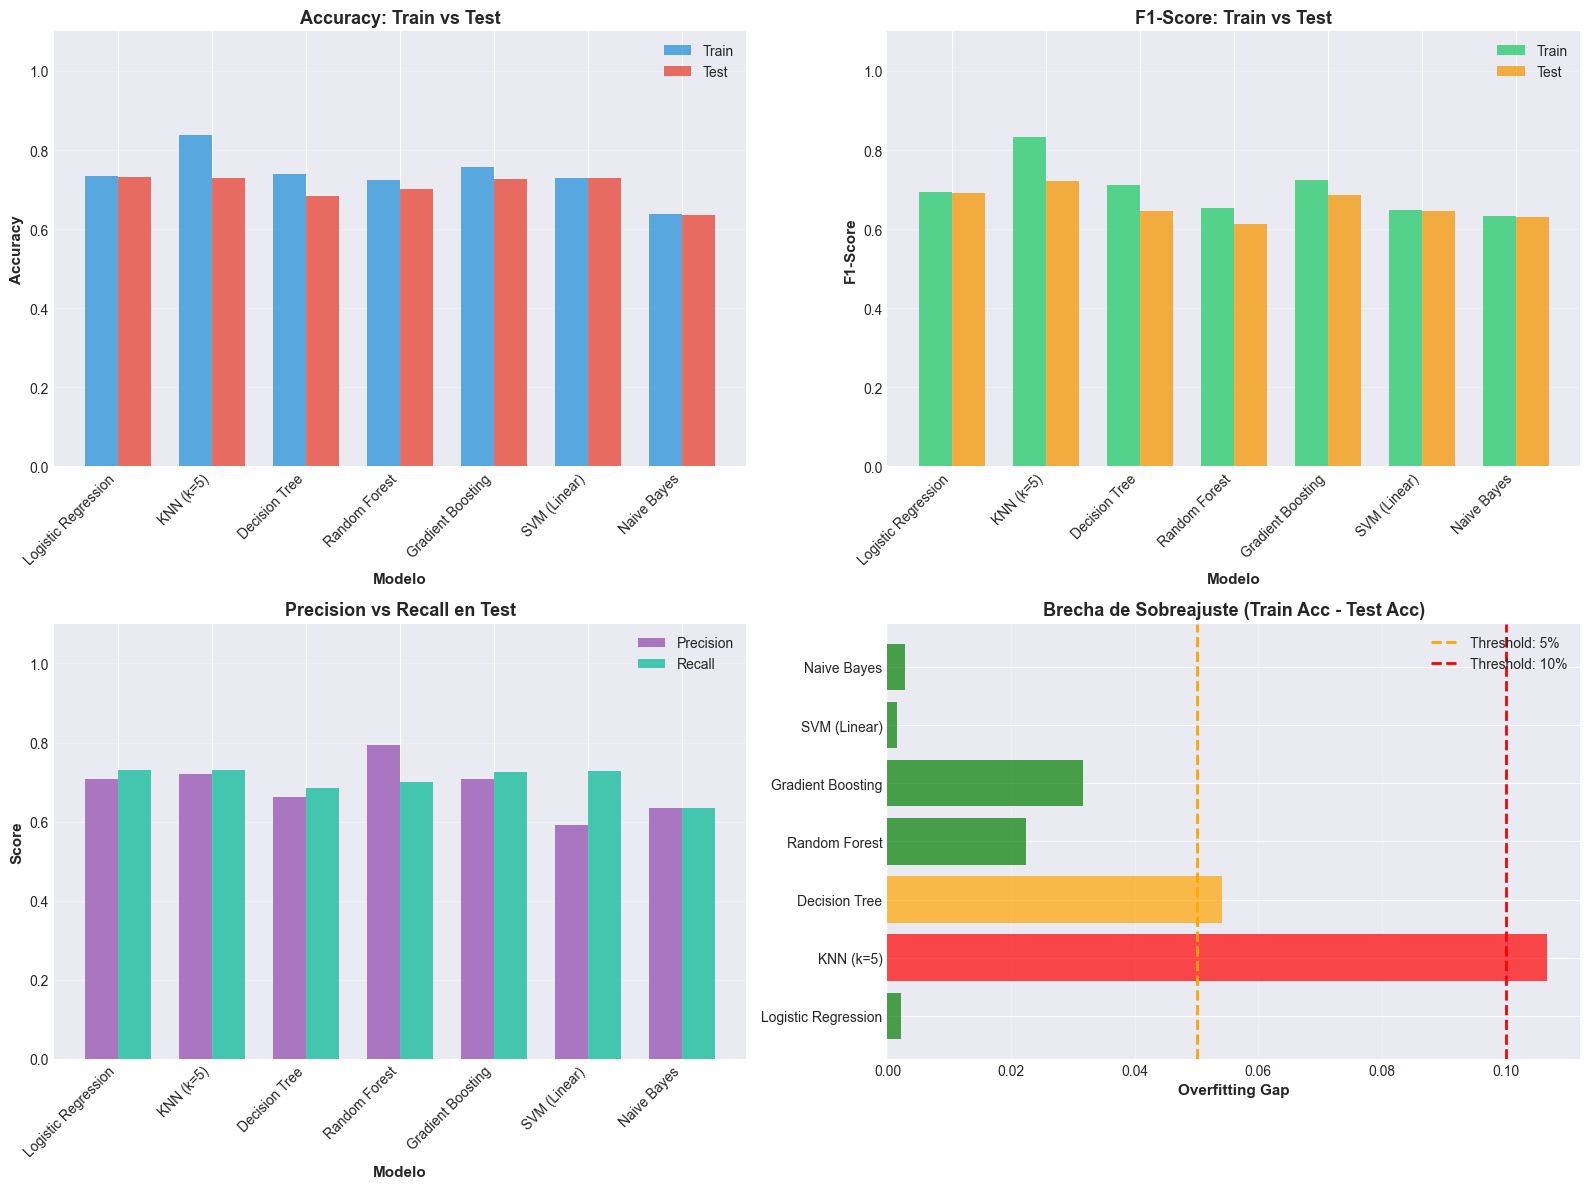

In [20]:
# Gráfico comparativo de accuracy
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Accuracy Train vs Test
x = np.arange(len(metrics_df))
width = 0.35
axes[0, 0].bar(x - width/2, metrics_df['Train Accuracy'], width, label='Train', color='#3498db', alpha=0.8)
axes[0, 0].bar(x + width/2, metrics_df['Test Accuracy'], width, label='Test', color='#e74c3c', alpha=0.8)
axes[0, 0].set_xlabel('Modelo', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Accuracy: Train vs Test', fontsize=13, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics_df['Modelo'], rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([0, 1.1])

# F1-Score Train vs Test
axes[0, 1].bar(x - width/2, metrics_df['Train F1-Score'], width, label='Train', color='#2ecc71', alpha=0.8)
axes[0, 1].bar(x + width/2, metrics_df['Test F1-Score'], width, label='Test', color='#f39c12', alpha=0.8)
axes[0, 1].set_xlabel('Modelo', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('F1-Score', fontsize=11, fontweight='bold')
axes[0, 1].set_title('F1-Score: Train vs Test', fontsize=13, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(metrics_df['Modelo'], rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_ylim([0, 1.1])

# Precision y Recall en Test
axes[1, 0].bar(x - width/2, metrics_df['Test Precision'], width, label='Precision', color='#9b59b6', alpha=0.8)
axes[1, 0].bar(x + width/2, metrics_df['Test Recall'], width, label='Recall', color='#1abc9c', alpha=0.8)
axes[1, 0].set_xlabel('Modelo', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Score', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Precision vs Recall en Test', fontsize=13, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics_df['Modelo'], rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_ylim([0, 1.1])

# Overfitting Gap
colors = ['red' if gap > 0.1 else 'orange' if gap > 0.05 else 'green' for gap in metrics_df['Overfitting Gap']]
axes[1, 1].barh(metrics_df['Modelo'], metrics_df['Overfitting Gap'], color=colors, alpha=0.7)
axes[1, 1].set_xlabel('Overfitting Gap', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Brecha de Sobreajuste (Train Acc - Test Acc)', fontsize=13, fontweight='bold')
axes[1, 1].axvline(0.05, color='orange', linestyle='--', linewidth=2, label='Threshold: 5%')
axes[1, 1].axvline(0.1, color='red', linestyle='--', linewidth=2, label='Threshold: 10%')
axes[1, 1].legend()
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3 Matrices de Confusión

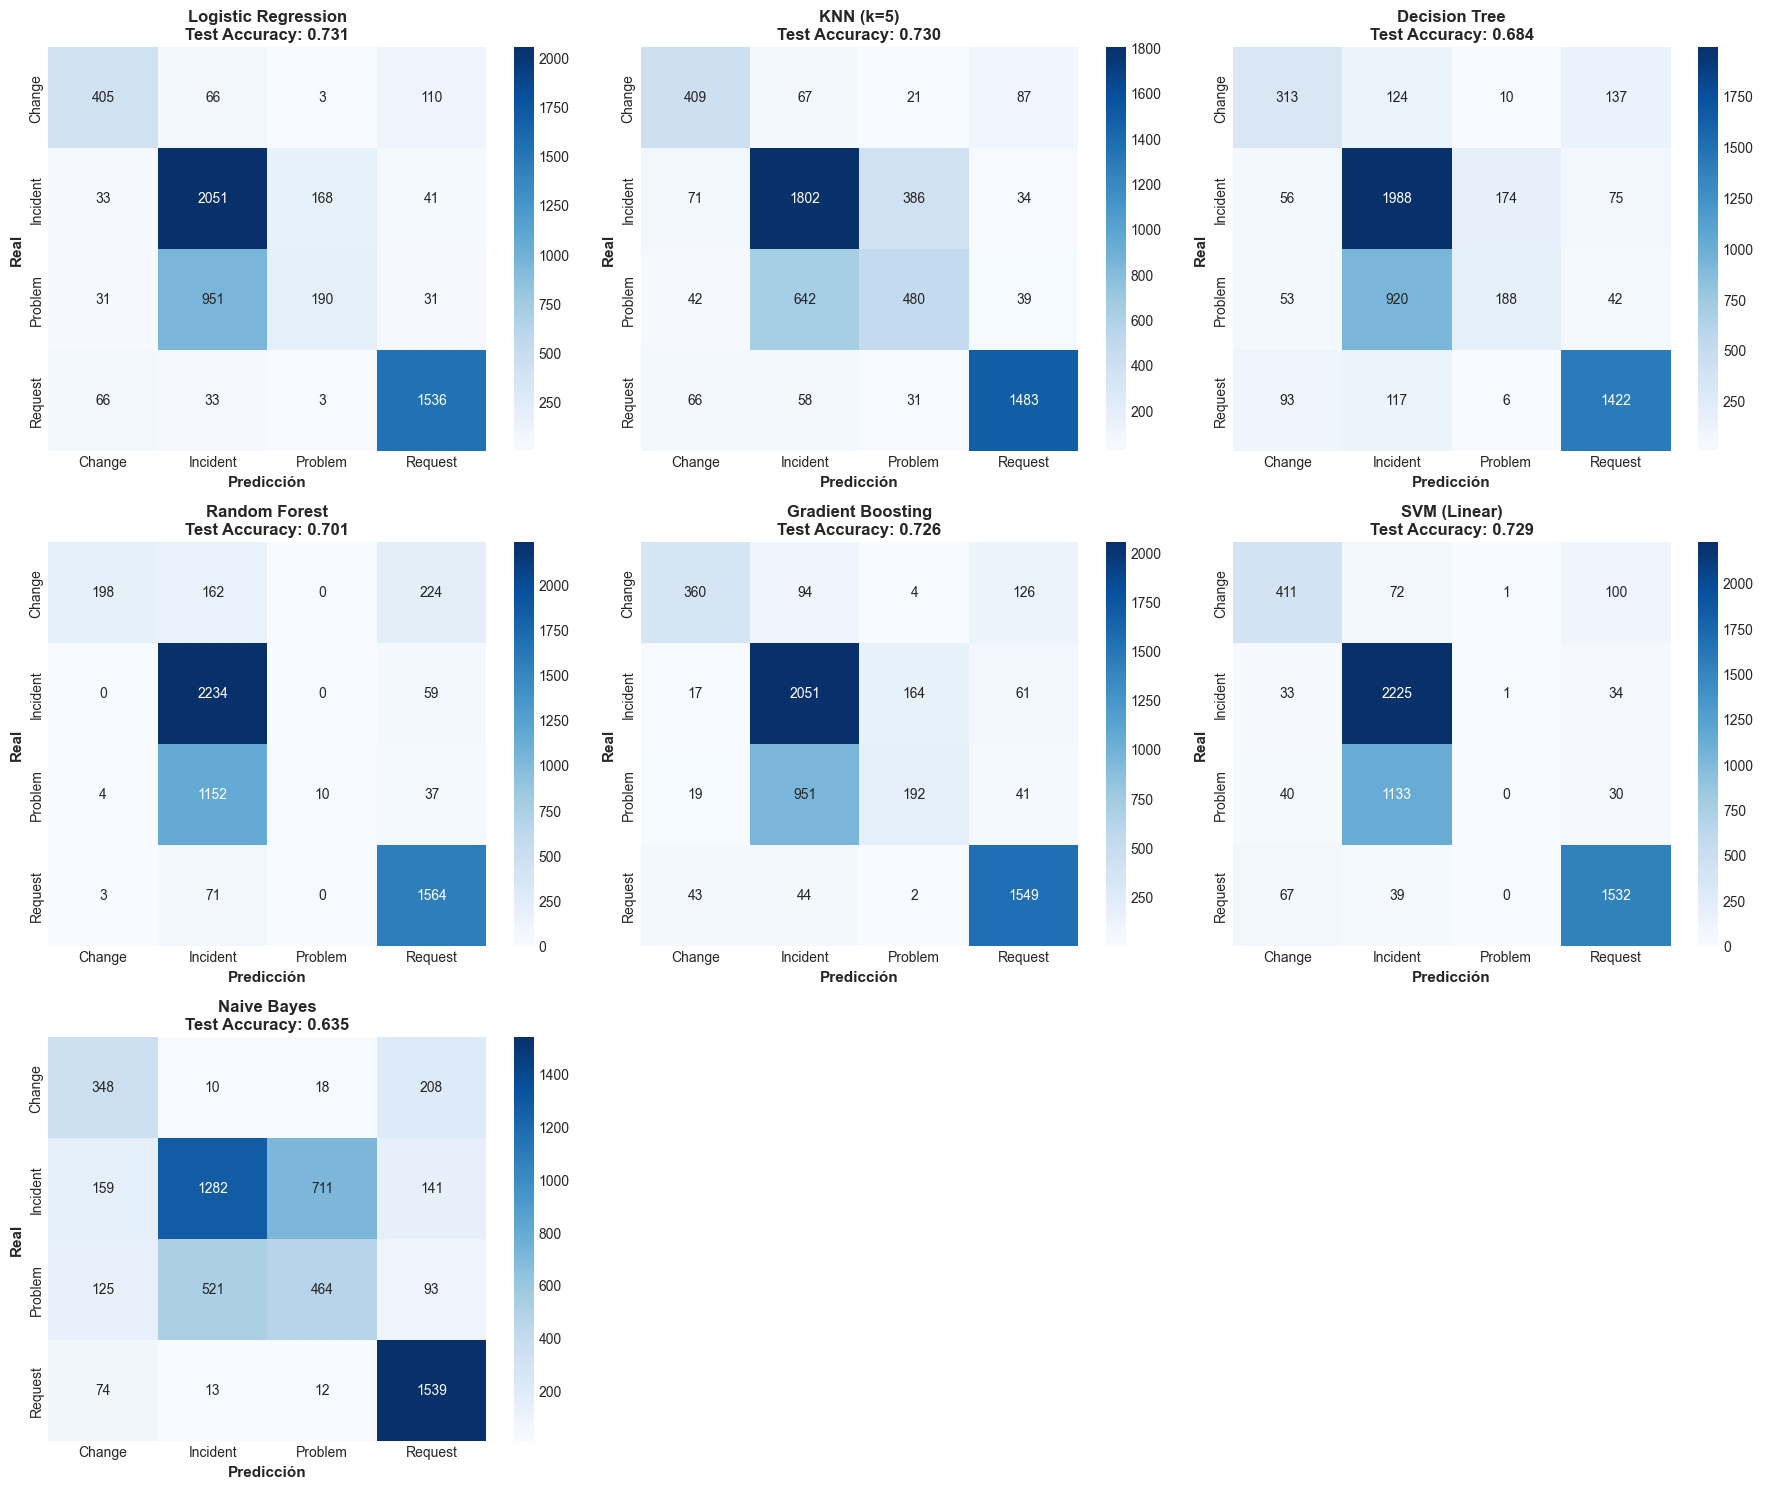

In [21]:
# Mostrar matrices de confusión para cada modelo
n_models = len(results)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.ravel() if n_models > 1 else [axes]

for idx, (name, result) in enumerate(results.items()):
    y_test_pred = result['y_test_pred']
    
    cm = confusion_matrix(y_test, y_test_pred)
    
    # Normalizar la matriz de confusión
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=True,
                xticklabels=np.unique(y), yticklabels=np.unique(y))
    axes[idx].set_ylabel('Real', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicción', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{name}\nTest Accuracy: {accuracy_score(y_test, y_test_pred):.3f}', 
                       fontsize=12, fontweight='bold')

# Ocultar ejes sobrantes
for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

**Interpretación de Matrices de Confusión:**

- **Diagonal principal:** Predicciones correctas
- **Fuera de la diagonal:** Errores de clasificación
- Un buen modelo tiene valores altos en la diagonal y bajos fuera de ella

### 5.4 Reportes de Clasificación Detallados

In [22]:
# Mostrar reporte de clasificación para los 3 mejores modelos
top_3_models = metrics_df.nlargest(3, 'Test F1-Score')['Modelo'].values

print("\n" + "="*80)
print("REPORTES DE CLASIFICACIÓN DETALLADOS - TOP 3 MODELOS")
print("="*80 + "\n")

for name in top_3_models:
    y_test_pred = results[name]['y_test_pred']
    print(f"\n{'='*80}")
    print(f"MODELO: {name}")
    print(f"{'='*80}\n")
    print(classification_report(y_test, y_test_pred, zero_division=0))


REPORTES DE CLASIFICACIÓN DETALLADOS - TOP 3 MODELOS


MODELO: KNN (k=5)

              precision    recall  f1-score   support

      Change       0.70      0.70      0.70       584
    Incident       0.70      0.79      0.74      2293
     Problem       0.52      0.40      0.45      1203
     Request       0.90      0.91      0.90      1638

    accuracy                           0.73      5718
   macro avg       0.71      0.70      0.70      5718
weighted avg       0.72      0.73      0.72      5718


MODELO: Logistic Regression

              precision    recall  f1-score   support

      Change       0.76      0.69      0.72       584
    Incident       0.66      0.89      0.76      2293
     Problem       0.52      0.16      0.24      1203
     Request       0.89      0.94      0.92      1638

    accuracy                           0.73      5718
   macro avg       0.71      0.67      0.66      5718
weighted avg       0.71      0.73      0.69      5718


MODELO: Gradient Boostin

## 6. Cross-Validation

Aplicaremos validación cruzada para obtener una evaluación más robusta del rendimiento de los modelos.

In [23]:
# Aplicar cross-validation con k=5 folds
print("\n" + "="*80)
print("VALIDACIÓN CRUZADA (5-FOLD STRATIFIED)")
print("="*80 + "\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in models.items():
    print(f"🔄 Ejecutando CV para {name}...", end=' ')
    
    # Usar datos escalados para modelos sensibles
    if name in ['Logistic Regression', 'KNN (k=5)', 'SVM (Linear)']:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    else:
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    
    cv_results.append({
        'Modelo': name,
        'CV Mean': scores.mean(),
        'CV Std': scores.std(),
        'CV Min': scores.min(),
        'CV Max': scores.max()
    })
    
    print(f"✓ (Mean: {scores.mean():.4f} ± {scores.std():.4f})")

cv_results_df = pd.DataFrame(cv_results).round(4)

# Combinar con resultados de test único
comparison_df = metrics_df[['Modelo', 'Test Accuracy']].merge(cv_results_df, on='Modelo')
comparison_df['Difference (Test - CV Mean)'] = (comparison_df['Test Accuracy'] - comparison_df['CV Mean']).round(4)

print("\n" + "="*80)
print("COMPARACIÓN: TEST ÚNICO VS CROSS-VALIDATION")
print("="*80 + "\n")
print(comparison_df.to_string(index=False))


VALIDACIÓN CRUZADA (5-FOLD STRATIFIED)

🔄 Ejecutando CV para Logistic Regression... ✓ (Mean: 0.7268 ± 0.0027)
🔄 Ejecutando CV para KNN (k=5)... ✓ (Mean: 0.7219 ± 0.0034)
🔄 Ejecutando CV para Decision Tree... ✓ (Mean: 0.6760 ± 0.0060)
🔄 Ejecutando CV para Random Forest... ✓ (Mean: 0.6964 ± 0.0042)
🔄 Ejecutando CV para Gradient Boosting... ✓ (Mean: 0.7276 ± 0.0041)
🔄 Ejecutando CV para SVM (Linear)... ✓ (Mean: 0.7254 ± 0.0028)
🔄 Ejecutando CV para Naive Bayes... ✓ (Mean: 0.6348 ± 0.0082)

COMPARACIÓN: TEST ÚNICO VS CROSS-VALIDATION

             Modelo  Test Accuracy  CV Mean  CV Std  CV Min  CV Max  Difference (Test - CV Mean)
Logistic Regression         0.7314   0.7268  0.0027  0.7228  0.7313                       0.0046
          KNN (k=5)         0.7300   0.7219  0.0034  0.7158  0.7258                       0.0081
      Decision Tree         0.6840   0.6760  0.0060  0.6657  0.6826                       0.0080
      Random Forest         0.7006   0.6964  0.0042  0.6914  0.7040       

### 6.1 Visualización de Cross-Validation

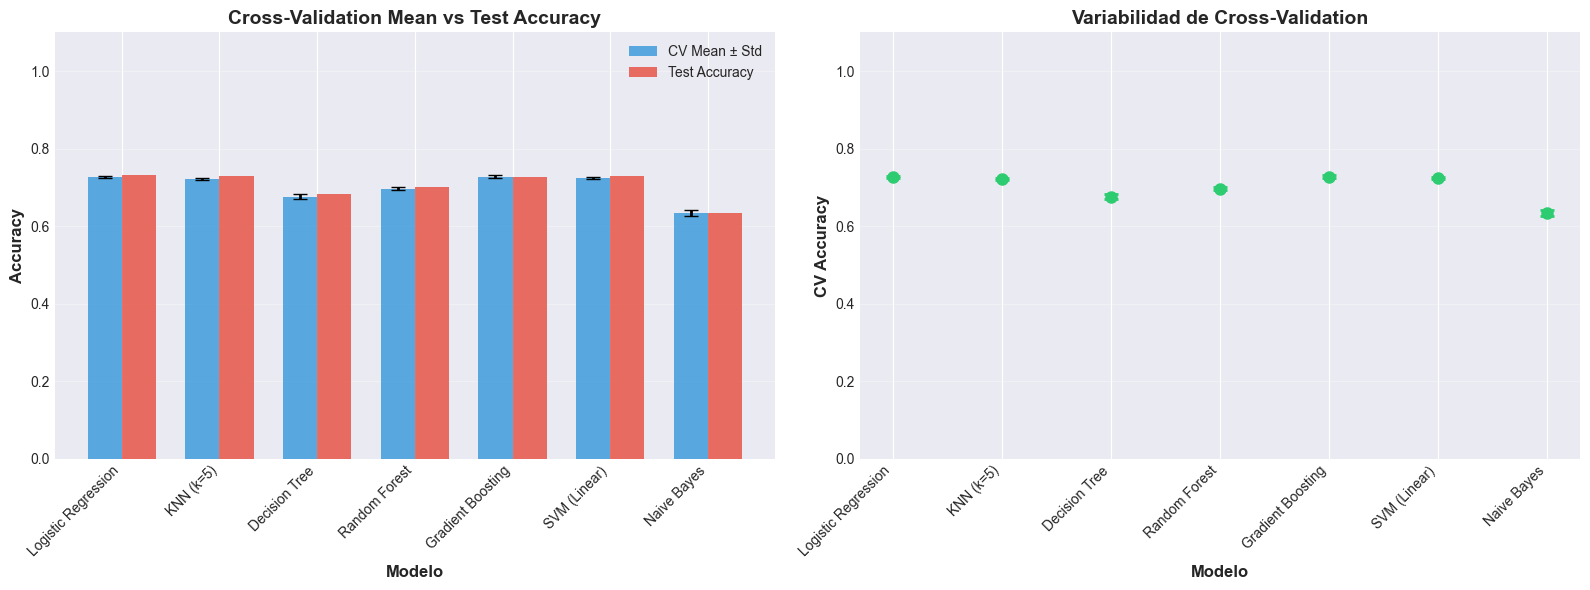

In [24]:
# Gráfico de comparación CV vs Test
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: CV Mean vs Test Accuracy
x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x - width/2, comparison_df['CV Mean'], width, 
           yerr=comparison_df['CV Std'], capsize=5, label='CV Mean ± Std', 
           color='#3498db', alpha=0.8, error_kw={'linewidth': 2})
axes[0].bar(x + width/2, comparison_df['Test Accuracy'], width, 
           label='Test Accuracy', color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('Modelo', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Cross-Validation Mean vs Test Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Modelo'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.1])

# Gráfico 2: Variabilidad de CV (barras de error)
axes[1].errorbar(comparison_df['Modelo'], comparison_df['CV Mean'], 
                yerr=comparison_df['CV Std'], fmt='o', markersize=8, 
                capsize=5, capthick=2, linewidth=2, color='#2ecc71')
axes[1].set_xlabel('Modelo', fontsize=12, fontweight='bold')
axes[1].set_ylabel('CV Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Variabilidad de Cross-Validation', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

**Interpretación:**

- **Baja desviación estándar:** Indica que el modelo es consistente entre diferentes particiones de datos
- **CV Mean similar a Test Accuracy:** Sugiere que el modelo generaliza bien
- **Gran diferencia entre CV y Test:** Puede indicar problemas de generalización o partición desafortunada

## 7. Interpretación y Conclusiones

### 7.1 Análisis de Diferencias entre Train, Test y Cross-Validation

In [25]:
# Crear tabla resumen completa
final_summary = metrics_df[['Modelo', 'Train Accuracy', 'Test Accuracy']].merge(
    cv_results_df[['Modelo', 'CV Mean', 'CV Std']], on='Modelo'
)
final_summary['Overfitting Gap'] = (final_summary['Train Accuracy'] - final_summary['Test Accuracy']).round(4)
final_summary['Generalization Score'] = (final_summary['CV Mean'] / final_summary['Train Accuracy']).round(4)

print("\n" + "="*80)
print("RESUMEN FINAL: TRAIN, TEST Y CROSS-VALIDATION")
print("="*80 + "\n")
print(final_summary.to_string(index=False))

print("\n" + "="*80)
print("ANÁLISIS DE SOBREAJUSTE")
print("="*80 + "\n")

for _, row in final_summary.iterrows():
    print(f"\n📊 {row['Modelo']}:")
    print(f"   Train Accuracy: {row['Train Accuracy']:.4f}")
    print(f"   Test Accuracy: {row['Test Accuracy']:.4f}")
    print(f"   CV Mean: {row['CV Mean']:.4f} ± {row['CV Std']:.4f}")
    print(f"   Overfitting Gap: {row['Overfitting Gap']:.4f}")
    
    if row['Overfitting Gap'] > 0.1:
        print("   ⚠️  ALTO SOBREAJUSTE - El modelo memoriza datos de entrenamiento")
    elif row['Overfitting Gap'] > 0.05:
        print("   ⚡ SOBREAJUSTE MODERADO - Considerar regularización")
    else:
        print("   ✓ BUEN EQUILIBRIO - El modelo generaliza correctamente")


RESUMEN FINAL: TRAIN, TEST Y CROSS-VALIDATION

             Modelo  Train Accuracy  Test Accuracy  CV Mean  CV Std  Overfitting Gap  Generalization Score
Logistic Regression          0.7335         0.7314   0.7268  0.0027           0.0021                0.9909
          KNN (k=5)          0.8367         0.7300   0.7219  0.0034           0.1067                0.8628
      Decision Tree          0.7382         0.6840   0.6760  0.0060           0.0542                0.9157
      Random Forest          0.7230         0.7006   0.6964  0.0042           0.0224                0.9632
  Gradient Boosting          0.7577         0.7261   0.7276  0.0041           0.0316                0.9603
       SVM (Linear)          0.7304         0.7289   0.7254  0.0028           0.0015                0.9932
        Naive Bayes          0.6382         0.6354   0.6348  0.0082           0.0028                0.9947

ANÁLISIS DE SOBREAJUSTE


📊 Logistic Regression:
   Train Accuracy: 0.7335
   Test Accuracy: 0.

### 7.2 Análisis de Importancia de Features (para modelos aplicables)


TOP 20 FEATURES MÁS IMPORTANTES (Random Forest)

 Feature  Importance
tfidf_61    0.106009
tfidf_43    0.090907
tfidf_23    0.057457
tfidf_65    0.052334
tfidf_39    0.040194
tfidf_66    0.033716
tfidf_44    0.027934
tfidf_94    0.022299
tfidf_30    0.021234
tfidf_13    0.020660
tfidf_68    0.019657
tfidf_67    0.019551
tfidf_41    0.019311
tfidf_76    0.019192
tfidf_29    0.019180
tfidf_55    0.018834
tfidf_40    0.018216
tfidf_62    0.017337
tfidf_86    0.016986
tfidf_36    0.016822


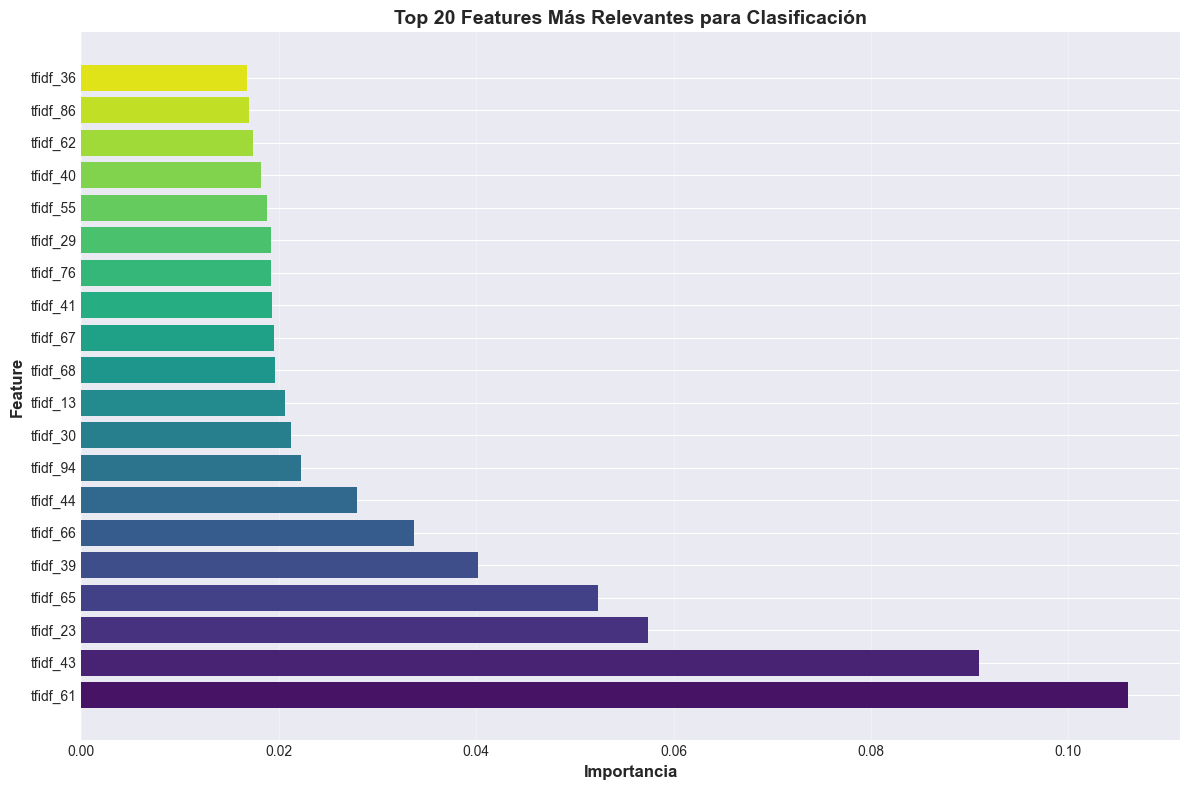


✓ Análisis de importancia de features completado


In [26]:
# Extraer importancia de features para Random Forest
if 'Random Forest' in results:
    rf_model = results['Random Forest']['model']
    
    # Obtener importancias
    feature_names = feature_cols + [f'tfidf_{i}' for i in range(text_features.shape[1])]
    importances = rf_model.feature_importances_
    
    # Crear dataframe de importancias
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(20)
    
    print("\n" + "="*80)
    print("TOP 20 FEATURES MÁS IMPORTANTES (Random Forest)")
    print("="*80 + "\n")
    print(feature_importance_df.to_string(index=False))
    
    # Visualización
    plt.figure(figsize=(12, 8))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], 
             color=sns.color_palette("viridis", len(feature_importance_df)))
    plt.xlabel('Importancia', fontsize=12, fontweight='bold')
    plt.ylabel('Feature', fontsize=12, fontweight='bold')
    plt.title('Top 20 Features Más Relevantes para Clasificación', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n✓ Análisis de importancia de features completado")

**Interpretación:**

- Las features con mayor importancia tienen más peso en la decisión de clasificación
- Features TF-IDF con alta importancia indican palabras clave discriminativas
- Features categóricas importantes (priority, queue) muestran su relevancia para la clasificación

### 7.3 Ranking Final de Modelos


🏆 RANKING FINAL DE MODELOS 🏆

                Modelo  Test Accuracy  CV Mean  F1-Score  Overfitting Gap  Composite Score
1  Logistic Regression         0.7314   0.7268    0.6921           0.0021           0.7602
2    Gradient Boosting         0.7261   0.7276    0.6861           0.0316           0.7529
3            KNN (k=5)         0.7300   0.7219    0.7227           0.1067           0.7502
4         SVM (Linear)         0.7289   0.7254    0.6469           0.0015           0.7478
5        Random Forest         0.7006   0.6964    0.6122           0.0224           0.7188
6        Decision Tree         0.6840   0.6760    0.6470           0.0542           0.7116
7          Naive Bayes         0.6354   0.6348    0.6294           0.0028           0.6880

RESUMEN Y RECOMENDACIONES

🥇 MEJOR MODELO: Logistic Regression
   - Test Accuracy: 0.7314
   - CV Mean: 0.7268
   - F1-Score: 0.6921
   - Overfitting Gap: 0.0021

🥈 SEGUNDO LUGAR: Gradient Boosting
🥉 TERCER LUGAR: KNN (k=5)

CONCLUSIONES

1

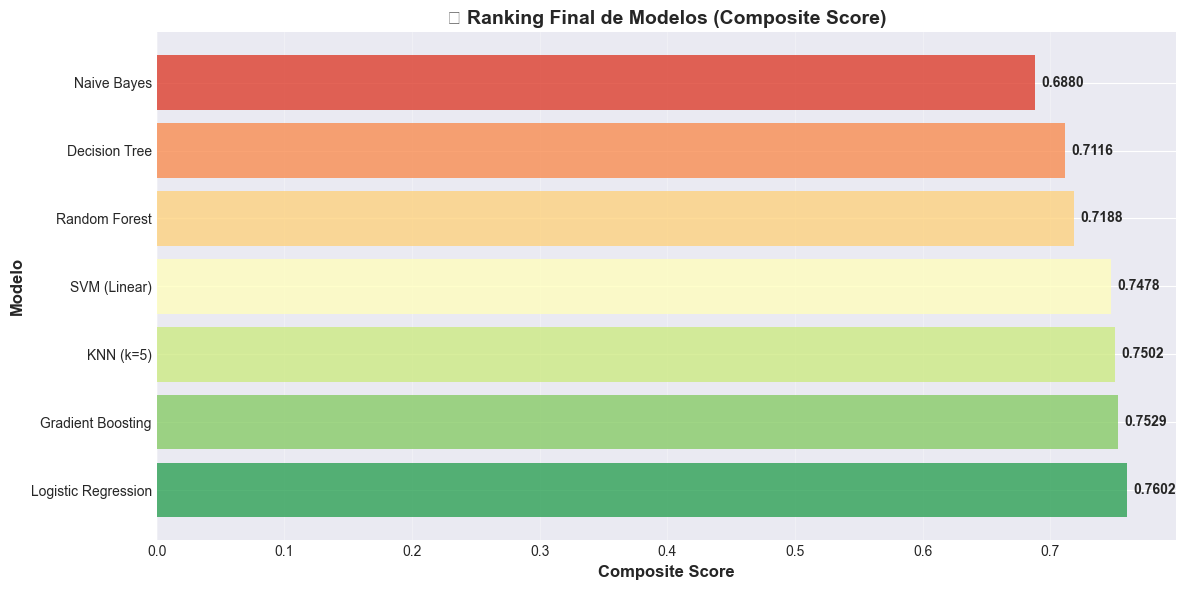

In [27]:
# Crear ranking basado en múltiples criterios
ranking_df = final_summary.copy()
ranking_df['F1-Score'] = metrics_df['Test F1-Score']
ranking_df['Precision'] = metrics_df['Test Precision']
ranking_df['Recall'] = metrics_df['Test Recall']

# Calcular score compuesto (puedes ajustar los pesos según necesidad)
ranking_df['Composite Score'] = (
    0.30 * ranking_df['Test Accuracy'] +
    0.30 * ranking_df['CV Mean'] +
    0.25 * ranking_df['F1-Score'] +
    0.15 * (1 - ranking_df['Overfitting Gap'].clip(0, 1))  # Penalizar overfitting
).round(4)

# Ordenar por score compuesto
ranking_df = ranking_df.sort_values('Composite Score', ascending=False).reset_index(drop=True)
ranking_df.index = ranking_df.index + 1

print("\n" + "="*80)
print("🏆 RANKING FINAL DE MODELOS 🏆")
print("="*80 + "\n")
print(ranking_df[['Modelo', 'Test Accuracy', 'CV Mean', 'F1-Score', 'Overfitting Gap', 'Composite Score']].to_string())

print("\n" + "="*80)
print("RESUMEN Y RECOMENDACIONES")
print("="*80 + "\n")

best_model = ranking_df.iloc[0]['Modelo']
print(f"🥇 MEJOR MODELO: {best_model}")
print(f"   - Test Accuracy: {ranking_df.iloc[0]['Test Accuracy']:.4f}")
print(f"   - CV Mean: {ranking_df.iloc[0]['CV Mean']:.4f}")
print(f"   - F1-Score: {ranking_df.iloc[0]['F1-Score']:.4f}")
print(f"   - Overfitting Gap: {ranking_df.iloc[0]['Overfitting Gap']:.4f}")

print(f"\n🥈 SEGUNDO LUGAR: {ranking_df.iloc[1]['Modelo']}")
print(f"🥉 TERCER LUGAR: {ranking_df.iloc[2]['Modelo']}")

print("\n" + "="*80)
print("CONCLUSIONES")
print("="*80 + "\n")

print("""1. **Rendimiento General:** 
   Los modelos ensemble (Random Forest, Gradient Boosting) tienden a tener mejor rendimiento
   que modelos lineales simples debido a la complejidad de los datos de texto.

2. **Overfitting:**
   - Modelos complejos (Decision Tree sin restricciones) muestran signos de sobreajuste
   - La regularización y validación cruzada son esenciales para evaluar correctamente

3. **Consistencia:**
   - La cross-validation proporciona una estimación más robusta del rendimiento real
   - Modelos con baja desviación estándar en CV son más confiables en producción

4. **Features Relevantes:**
   - Las palabras clave del texto (TF-IDF) son altamente discriminativas
   - Variables categóricas como priority y queue aportan información valiosa

5. **Recomendación Final:**
   Para producción, se recomienda el modelo con mejor equilibrio entre accuracy, 
   consistencia (CV) y bajo overfitting. Considerar también el tiempo de inferencia
   y requisitos de interpretabilidad del negocio.
""")

# Visualización del ranking
plt.figure(figsize=(12, 6))
colors = sns.color_palette("RdYlGn_r", len(ranking_df))
plt.barh(ranking_df['Modelo'], ranking_df['Composite Score'], color=colors, alpha=0.8)
plt.xlabel('Composite Score', fontsize=12, fontweight='bold')
plt.ylabel('Modelo', fontsize=12, fontweight='bold')
plt.title('🏆 Ranking Final de Modelos (Composite Score)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Añadir valores
for i, v in enumerate(ranking_df['Composite Score']):
    plt.text(v + 0.005, i, f"{v:.4f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Próximos Pasos

Para mejorar aún más el rendimiento del modelo, considera:

1. **Optimización de Hiperparámetros:** Usar GridSearchCV o RandomizedSearchCV para encontrar los mejores parámetros
2. **Técnicas de Balanceo:** Aplicar SMOTE, oversampling o undersampling si hay desbalanceo significativo
3. **Feature Engineering Avanzado:** 
   - Usar embeddings pre-entrenados (Word2Vec, GloVe, BERT)
   - Crear features de interacción entre variables
4. **Ensemble de Modelos:** Combinar predicciones de múltiples modelos (stacking, voting)
5. **Análisis de Errores:** Estudiar en detalle los casos mal clasificados para identificar patrones
6. **Validación Temporal:** Si los datos tienen componente temporal, usar time-series split
7. **Deployment:** Preparar el modelo para producción con MLflow, FastAPI o similar